In [1]:
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

import os
while not os.path.isdir('.git'):
    os.chdir('../..')

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

In [4]:
project = "temporal-interference-1"

In [5]:
subthreshold = []

for file in glob.glob(f"output/{project}/ef/*_*_*.csv"):
    pattern = re.compile(r"([^/]+)_([^/]+)_([^/]+)\.csv$")
    phi, psi, carrier = pattern.search(file).groups()

    data = pd.read_csv(file)
    data["Phi"] = int(phi)
    data["Psi"] = int(psi)
    data["Carrier"] = int(carrier)

    subthreshold.append(data)

subthreshold = pd.concat(subthreshold, ignore_index = True)

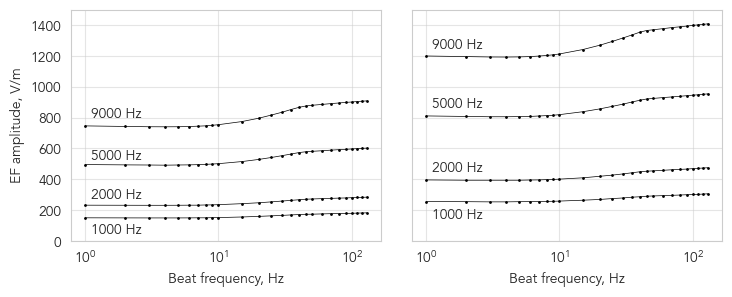

In [35]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (8.4, 3))
axs = axs.flatten()

carriers = [1000, 2000, 5000, 9000]
color = "black"

ax = axs[0]

x = 1.1
ys = {
    1000: 20,
    2000: 250,
    5000: 500,
    9000: 775
}

for carrier in carriers:
    dt = subthreshold[
        (subthreshold.Phi == 90) &
        (subthreshold.Psi == 90) &
        (subthreshold.Carrier == carrier) &
        (subthreshold.Offset > 0.5)
    ]

    ax.plot(dt.Offset, dt.Amplitude, linewidth = 0.5, color = color)
    ax.scatter(dt.Offset, dt.Amplitude, s = 1, color = color)
    
    ax.text(
        x, ys[carrier],
        f"{carrier} Hz",
        fontsize = 10,
        horizontalalignment = "left",
        verticalalignment = "bottom"
    )

ax.set_xlabel("Beat frequency, Hz")
ax.set_ylabel("EF amplitude, V/m")
ax.set_xscale("log")
ax.grid(alpha = 0.5)
ax.set_ylim(0, 1500)

ax = axs[1]

x = 1.1
ys = {
    1000: 120,
    2000: 420,
    5000: 840,
    9000: 1220
}

for carrier in carriers:
    dt = subthreshold[
        (subthreshold.Phi == 0) &
        (subthreshold.Psi == 180) &
        (subthreshold.Carrier == carrier) &
        (subthreshold.Offset > 0.5)
    ]

    ax.plot(dt.Offset, dt.Amplitude, linewidth = 0.5, color = color)
    ax.scatter(dt.Offset, dt.Amplitude, s = 1, color = color)

    ax.text(
        x, ys[carrier],
        f"{carrier} Hz",
        fontsize = 10,
        horizontalalignment = "left",
        verticalalignment = "bottom"
    )

ax.set_xlabel("Beat frequency, Hz")
ax.set_xscale("log")
ax.grid(alpha = 0.5)
ax.set_ylim(0, 1500)
ax.tick_params(left = False, labelleft = False)

plt.subplots_adjust(wspace = 0.1)
plt.savefig("bernstein-ef-1.png", dpi = 500, bbox_inches = "tight")